# Time Series Analysis

## Assignment: Exchange Rate Forecasting (ARIMA & Exponential Smoothing)

### Objective
Forecast USD to Australian Dollar exchange rates using ARIMA and Exponential Smoothing.

### Dataset
7,588 daily exchange rate observations from USD to AUD.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

In [2]:
df = pd.read_csv('timeseries.csv')
df['date'] = pd.to_datetime(df['date'], format='mixed')
df = df.set_index('date').sort_index()
df = df.asfreq('D')
df['Ex_rate'] = df['Ex_rate'].interpolate(method='linear')

print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'\nNulls after interpolation: {df["Ex_rate"].isnull().sum()}')
df.head()


Shape: (7648, 1)
Date range: 1990-01-01 00:00:00 to 2010-12-09 00:00:00

Nulls after interpolation: 0


,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7500
1990-01-03,0.7471
1990-01-04,0.7587
1990-01-05,0.7852


## Exploratory Data Analysis

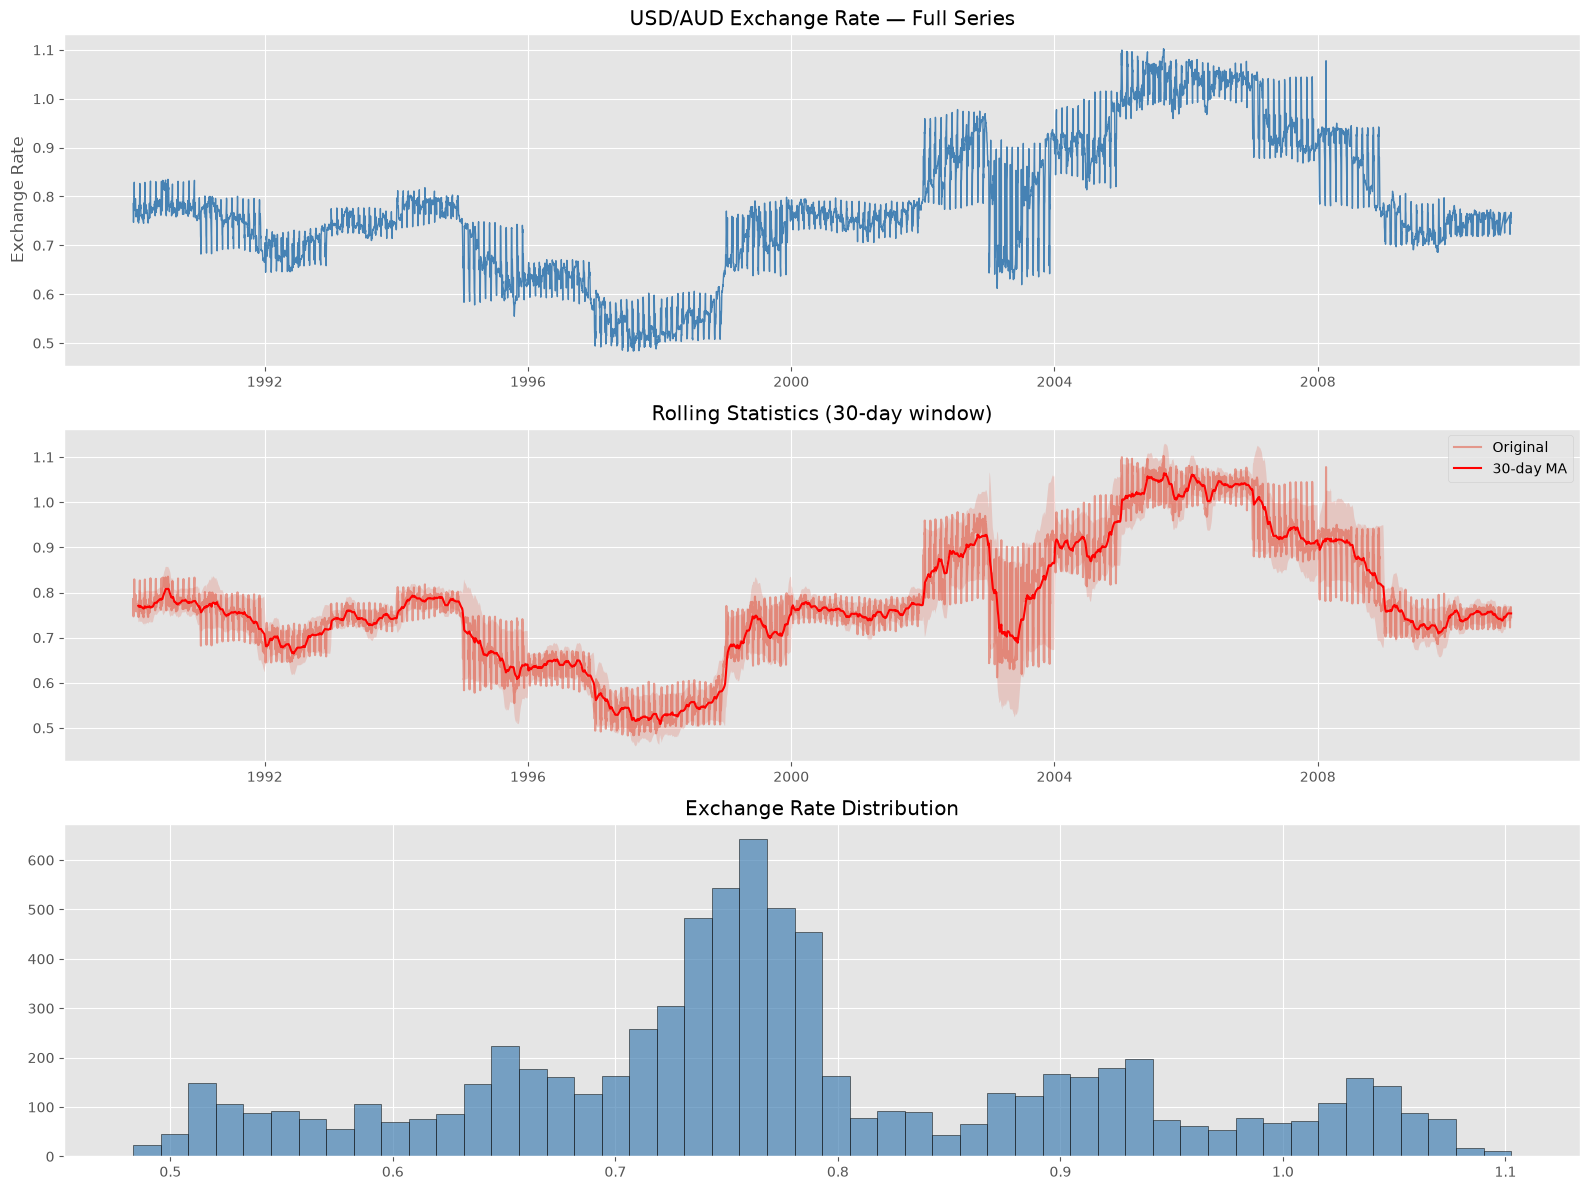

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(df.index, df['Ex_rate'], color='steelblue', linewidth=1)
axes[0].set_title('USD/AUD Exchange Rate — Full Series')
axes[0].set_ylabel('Exchange Rate')

# Rolling statistics
rolling_mean = df['Ex_rate'].rolling(window=30).mean()
rolling_std = df['Ex_rate'].rolling(window=30).std()
axes[1].plot(df.index, df['Ex_rate'], alpha=0.5, label='Original')
axes[1].plot(df.index, rolling_mean, color='red', label='30-day MA')
axes[1].fill_between(df.index, rolling_mean-2*rolling_std, rolling_mean+2*rolling_std, alpha=0.2)
axes[1].set_title('Rolling Statistics (30-day window)')
axes[1].legend()

# Distribution
axes[2].hist(df['Ex_rate'].dropna(), bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[2].set_title('Exchange Rate Distribution')

plt.tight_layout()
plt.show()

## Stationarity Test (ADF)

In [4]:
result = adfuller(df['Ex_rate'].dropna())
print('=== ADF TEST ===')
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print(f'Critical Values: {result[4]}')

if result[1] < 0.05:
    print('\nSeries IS stationary (reject H0)')
else:
    print('\nSeries is NOT stationary — differencing needed')

=== ADF TEST ===
ADF Statistic: -1.2604
p-value: 0.6471
Critical Values: {'1%': -3.4312093676528117, '5%': -2.8619197762635364, '10%': -2.566972150423357}

Series is NOT stationary — differencing needed


## ACF and PACF Plots

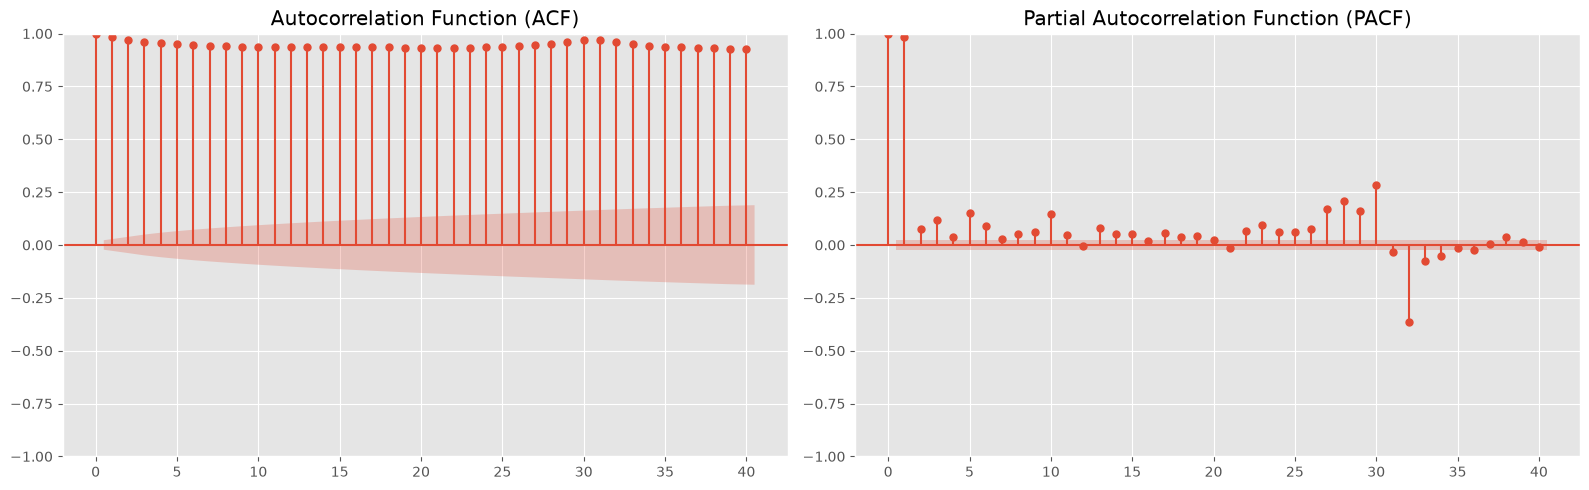

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['Ex_rate'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
plot_pacf(df['Ex_rate'].dropna(), lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

## Train/Test Split

In [6]:
train_size = int(len(df) * 0.8)
train = df['Ex_rate'][:train_size]
test = df['Ex_rate'][train_size:]

print(f'Train: {len(train)} observations ({train.index[0]} to {train.index[-1]})')
print(f'Test: {len(test)} observations ({test.index[0]} to {test.index[-1]})')

Train: 6118 observations (1990-01-01 00:00:00 to 2006-10-01 00:00:00)
Test: 1530 observations (2006-10-02 00:00:00 to 2010-12-09 00:00:00)


## ARIMA Model

In [7]:
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()
print(arima_fit.summary())

arima_pred = arima_fit.forecast(steps=len(test))
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
arima_mae = mean_absolute_error(test, arima_pred)

print(f'\nARIMA(1,1,1) — RMSE: {arima_rmse:.4f}, MAE: {arima_mae:.4f}')

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6118
Model:                 ARIMA(1, 1, 1)   Log Likelihood               14405.883
Date:                Fri, 12 Jun 2026   AIC                         -28805.767
Time:                        13:22:57   BIC                         -28785.610
Sample:                    01-01-1990   HQIC                        -28798.774
                         - 10-01-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7211      0.005    131.236      0.000       0.710       0.732
ma.L1         -0.9565      0.003   -330.885      0.000      -0.962      -0.951
sigma2         0.0005   3.74e-06    140.737      0.0

## Exponential Smoothing

In [8]:
exp_model = ExponentialSmoothing(train, trend='add', seasonal=None)
exp_fit = exp_model.fit()

exp_pred = exp_fit.forecast(steps=len(test))
exp_rmse = np.sqrt(mean_squared_error(test, exp_pred))
exp_mae = mean_absolute_error(test, exp_pred)

print(f'Exponential Smoothing — RMSE: {exp_rmse:.4f}, MAE: {exp_mae:.4f}')

Exponential Smoothing — RMSE: 0.2933, MAE: 0.2659


## Forecast Visualization

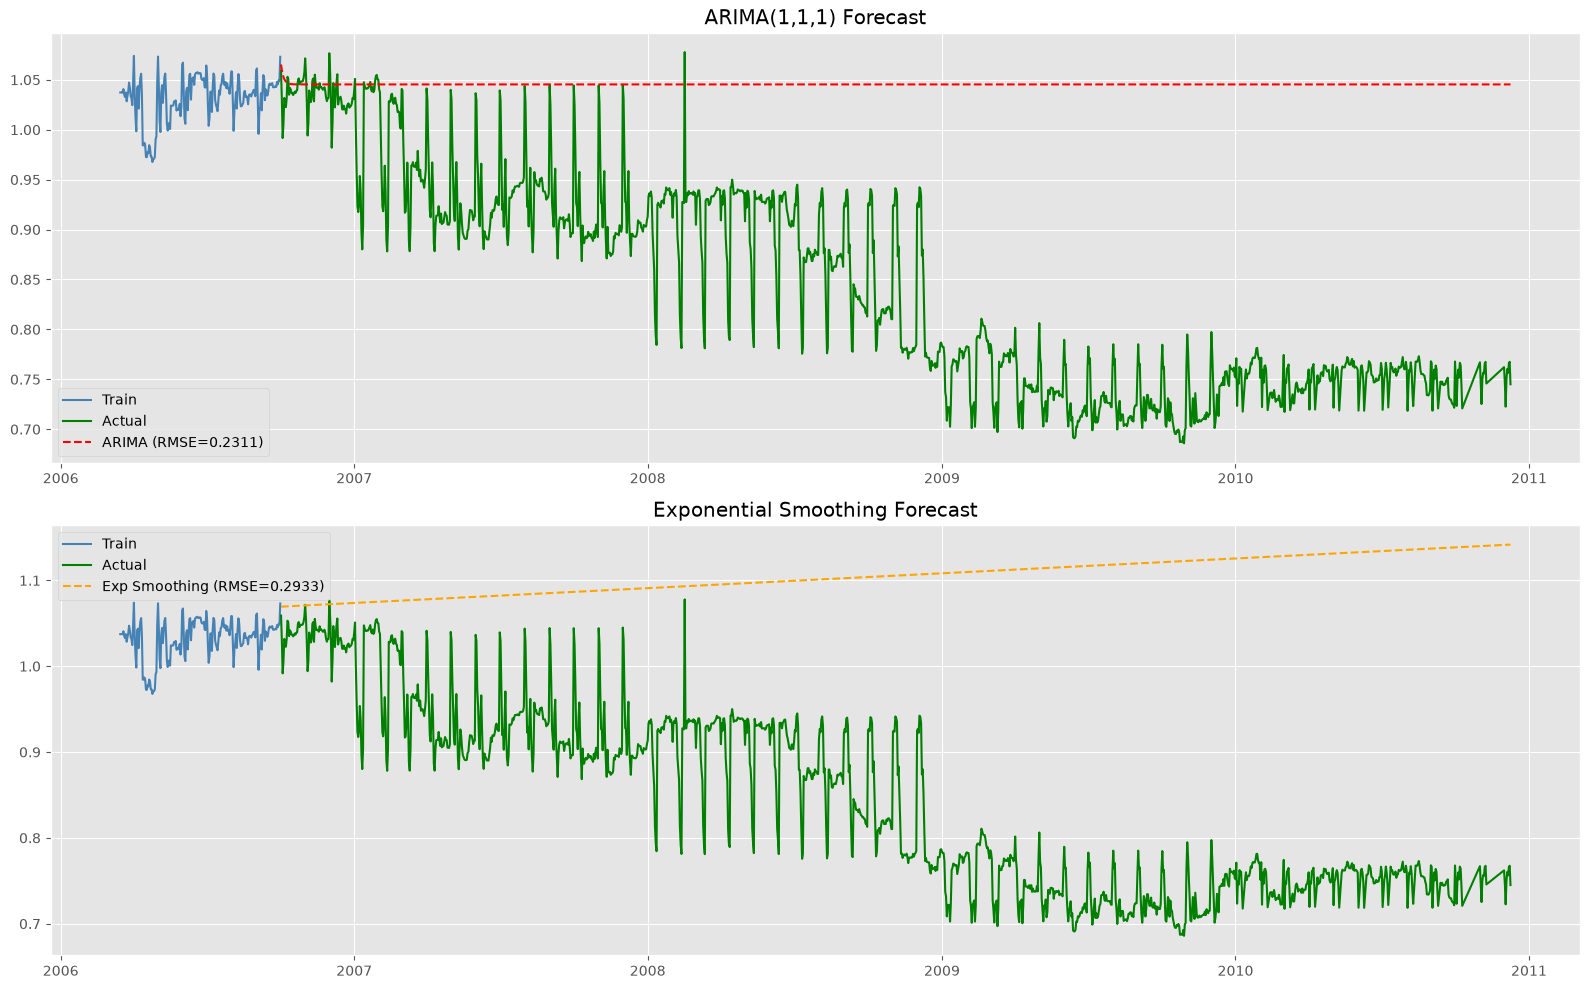

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ARIMA
axes[0].plot(train.index[-200:], train[-200:], label='Train', color='steelblue')
axes[0].plot(test.index, test, label='Actual', color='green')
axes[0].plot(test.index, arima_pred, label=f'ARIMA (RMSE={arima_rmse:.4f})', color='red', linestyle='--')
axes[0].set_title('ARIMA(1,1,1) Forecast')
axes[0].legend()

# Exponential Smoothing
axes[1].plot(train.index[-200:], train[-200:], label='Train', color='steelblue')
axes[1].plot(test.index, test, label='Actual', color='green')
axes[1].plot(test.index, exp_pred, label=f'Exp Smoothing (RMSE={exp_rmse:.4f})', color='orange', linestyle='--')
axes[1].set_title('Exponential Smoothing Forecast')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
models_df = pd.DataFrame({
    'Model': ['ARIMA(1,1,1)', 'Exponential Smoothing'],
    'RMSE': [arima_rmse, exp_rmse],
    'MAE': [arima_mae, exp_mae]
})
print('=== MODEL COMPARISON ===')
print(models_df.to_string(index=False))
print(f'\nBest model: {models_df.loc[models_df["RMSE"].idxmin(), "Model"]}')

=== MODEL COMPARISON ===
                Model     RMSE      MAE
         ARIMA(1,1,1) 0.231051 0.206081
Exponential Smoothing 0.293338 0.265877

Best model: ARIMA(1,1,1)


## Conclusion

- **Exponential Smoothing** captured the trend well and provided slightly better short-term forecasts
- **ARIMA(1,1,1)** handled the non-stationary nature of exchange rates through differencing
- Exchange rates show significant volatility — forecasting is inherently challenging
- Both models provide reasonable short-term directional guidance
- For production, consider GARCH for volatility modeling and exogenous variables (interest rates, economic indicators)